# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Problem Framing and Literature Review

**Why malaria diagnosis needs AI**

Malaria remains one of the most deadly infectious diseases on the planet. According to the World Health Organization, there were over 249 million cases and more than 600,000 deaths in 2022, with children under five in sub-Saharan Africa bearing the heaviest burden (WHO, 2023). The traditional diagnostic method examining a stained blood smear under a microscope  is reliable in the hands of a skilled technician, but it's slow, labor-intensive, and expensive. In rural communities across Africa, the shortage of trained lab workers means patients often wait far too long for answers. Bringing AI into this pipeline could dramatically speed up diagnosis and reduce its cost, potentially saving thousands of lives.

**Convolutional Neural Networks for image classification**

The foundation for this work goes back to LeCun et al. (1998), who demonstrated that CNNs could learn meaningful visual features directly from raw pixels through gradient-based training eliminating the need for hand-engineered features. Since then, CNNs have become the go-to architecture for image classification. Simonyan and Zisserman (2014) introduced VGG16, showing that stacking many small 3×3 filters across a deep network outperformed older approaches using larger filters. VGG16 went on to achieve top results on ImageNet and became widely adopted for transfer learning tasks. He et al. (2016) tackled the vanishing gradient problem head-on with ResNet, using skip connections that let gradients bypass layers entirely. This made it possible to train networks with 50 or more layers effectively. Sandler et al. (2018) then took a different approach with MobileNetV2, prioritizing efficiency: by using depthwise separable convolutions and inverted residual blocks, they achieved competitive accuracy at a fraction of the computational cost. For contexts where hardware is limited like clinics in rural Africa this matters a great deal.

**Transfer learning in medical imaging**

Pan and Yang (2010) formally defined transfer learning as the process of leveraging knowledge gained in one domain to accelerate learning in another. In medical imaging, this idea is especially powerful because labeled datasets are hard to come by and expensive to produce. Tajbakhsh et al. (2016) demonstrated that fine-tuning pretrained CNNs on medical image data consistently outperforms training from scratch, particularly when fewer than 50,000 examples are available. The NIH malaria cell dataset we're using here contains roughly 27,000 images squarely in the range where transfer learning is not just helpful but strongly advisable.

**Malaria detection with CNNs**

Rajaraman et al. (2018) benchmarked multiple pretrained CNNs directly on the NIH dataset, finding that VGG16 could classify parasitized versus uninfected cells with over 95% accuracy. Their study is the primary motivation for our decision to include VGG16, ResNet50, and MobileNetV2 in this project. Importantly, they also found that fine-tuning the backbone rather than treating it purely as a fixed feature extractor consistently led to better results. That insight is what drives our progressive layer-unfreezing experiments.

**Regularization techniques**

Two regularization methods appear throughout this notebook. Srivastava et al. (2014) introduced dropout, which works by randomly zeroing out neuron activations during training, forcing the network to learn more robust, distributed representations. Ioffe and Szegedy (2015) introduced Batch Normalization, which standardizes activations within each mini-batch to reduce internal covariate shift. Beyond stabilizing training and speeding up convergence, Batch Normalization also provides a mild regularizing effect. Both techniques are used across the experiments described below.

**How this connects to our project**

Every model in this group is grounded in the literature above. Adossi's baseline CNN follows the classic Conv-Pool-Dense pattern from LeCun et al. (1998). Nehemie's advanced CNN layers in Batch Normalization (Ioffe & Szegedy, 2015) and Dropout (Srivastava et al., 2014). Berissa applies VGG16 (Simonyan & Zisserman, 2014) with the fine-tuning strategy endorsed by Rajaraman et al. (2018). Elvin uses ResNet50 (He et al., 2016) with frozen BatchNormalization layers, following established best practices for ResNet transfer learning. My contribution (Gabriel) focuses on MobileNetV2 (Sandler et al., 2018), which I chose because it's the most practical architecture for real-world deployment in low-resource clinical environments.

**References**

- He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *CVPR*, 770-778.
- Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *ICML*, 448-456.
- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278-2324.
- Pan, S. J., & Yang, Q. (2010). A survey on transfer learning. *IEEE Transactions on Knowledge and Data Engineering*, 22(10), 1345-1359.
- Rajaraman, S., Antani, S. K., Poostchi, M., Silamut, K., Hossain, M. A., Maude, R. J., & Jaeger, S. (2018). Pre-trained convolutional neural networks as feature extractors toward improved malaria parasite detection in thin blood smear images. *PeerJ*, 6, e4568.
- Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L. C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. *CVPR*, 4510-4520.
- Simonyan, K., & Zisserman, A. (2014). Very deep convolutional networks for large-scale image recognition. *ICLR*.
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Drozdov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *JMLR*, 15(1), 1929-1958.
- Tajbakhsh, N., et al. (2016). Convolutional neural networks for medical image analysis: Full training or fine tuning? *IEEE Transactions on Medical Imaging*, 35(5), 1299-1312.
- WHO. (2023). *World Malaria Report 2023*. World Health Organization.

## Environment Configuration

Before diving into the data, we need to set up the environment. This section mounts Google Drive (so our work persists across sessions) and checks that a GPU is available training these models on CPU alone would take far too long.

In [1]:
# Mount Google Drive (skip gracefully if not in Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive/')
    import os
    project_path = "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"
    if os.path.exists(project_path):
        import subprocess
        subprocess.run(['ls', project_path])
    else:
        print("Drive mounted but project folder not found — will use local paths.")
except ModuleNotFoundError:
    print("Not running in Colab — skipping Drive mount. Using local paths.")


Mounted at /content/drive/


In [2]:
import tensorflow as tf

# Enable mixed precision only when a GPU is available (speeds up training on GPU,
# but can cause issues on CPU-only environments)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision (float16) enabled — GPU detected.")
else:
    print("No GPU detected — running on CPU with float32.")

print(f"TensorFlow version: {tf.__version__}")
device = tf.test.gpu_device_name()
print(f"GPU device: {device if device else 'None (CPU mode)'}")


Mixed precision (float16) enabled — GPU detected.
TensorFlow version: 2.20.0
GPU device: /device:GPU:0


## Importing Libraries

Here we bring in everything we'll need: standard utilities for file handling, visualization tools, Keras for building and training models, and scikit-learn for evaluation metrics.

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Preparing the Dataset

This section handles getting the data ready downloading it, splitting it into training and test sets, and setting up the image generators that will feed batches into our models during training.

### Downloading the Dataset

We pull the malaria cell image dataset directly from the NIH. The `downloadData` flag lets you skip this step if you've already downloaded it in a previous session.

In [5]:
import os

# Set downloadData = True to fetch the dataset from NIH.
# Set it to False if you've already downloaded it in a previous session.
downloadData = True

if downloadData:
    indrive = False  # Set True to save directly to Google Drive instead

    if indrive:
        drive_path = "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
        if not os.path.exists(os.path.join(drive_path, 'cell_images')):
            !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "{drive_path}"
            !unzip "{drive_path}/cell_images.zip" -d "{drive_path}/"
        else:
            print("Dataset already exists in Drive — skipping download.")
        !ls "{drive_path}"
    else:
        # Download to the Colab runtime (faster I/O during training)
        if not os.path.exists('cell_images'):
            !rm -f cell_images.zip
            !wget -q https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
            !unzip -q cell_images.zip
            print("Dataset downloaded and extracted successfully.")
        else:
            print("cell_images folder already exists — skipping download.")
        !ls
else:
    print("downloadData=False — assuming dataset is already available locally.")


Dataset downloaded and extracted successfully.
cell_images  cell_images.zip  drive  sample_data


### Additional Imports

Now that the dataset is in place, we load the remaining libraries and define a few global constants image size, batch size, class names, and the maximum number of training epochs. We also fix the random seeds here to make sure our results are reproducible.

In [6]:
import warnings
import numpy as np
import seaborn as sns
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dropout, BatchNormalization,
                                      GlobalAveragePooling2D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras import callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_v2_preprocess

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

SEED       = 42
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
CLASSES    = ['Parasitized', 'Uninfected']
EPOCHS_MAX = 20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('Additional libraries loaded.')

Additional libraries loaded.


### Splitting into Training and Test Sets

We divide the data 80/20 between training and test sets. The split is done once and saved to disk, so calling `create_splits()` again won't shuffle things around unexpectedly unless you explicitly pass `rebuild=True`.

In [7]:
def create_splits(rebuild=False):
    if os.path.exists(training_path) and not rebuild:
        print('Folders already exist. Set rebuild=True to redo.')
        for sp in ['train', 'test']:
            for cls in CLASSES:
                print(f'  {sp}/{cls}: {len(os.listdir(os.path.join(sp, cls))):,}')
        return
    for sp in ['train', 'test']:
        if os.path.exists(sp): shutil.rmtree(sp)
    for sp in ['train', 'test']:
        for cls in CLASSES:
            os.makedirs(os.path.join(sp, cls), exist_ok=True)
    for cls in CLASSES:
        src   = os.path.join(cell_images_dir, cls)
        files = [f for f in os.listdir(src) if f.endswith('.png')]
        random.shuffle(files)
        n = len(files); n_tr = int(n * 0.80)
        for sp, fl in [('train', files[:n_tr]), ('test', files[n_tr:])]:
            for f in fl:
                shutil.copy(os.path.join(src, f), os.path.join(sp, cls, f))
            print(f'  {sp}/{cls}: {len(fl):,}')
    print('Split complete.')

create_splits(rebuild=False)

  train/Parasitized: 11,023
  test/Parasitized: 2,756
  train/Uninfected: 11,023
  test/Uninfected: 2,756
Split complete.


### Setting Up Data Generators

The `make_generators()` function handles image loading, preprocessing, and optional augmentation. When augmentation is enabled, training images are randomly flipped, rotated, and shifted this gives the model more varied examples to learn from and helps prevent overfitting.

In [8]:
def make_generators(batch_size=64, aug=False, preprocess_fn=None):
    if preprocess_fn is not None:
        aug_cfg   = dict(preprocessing_function=preprocess_fn, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(preprocessing_function=preprocess_fn)
        te_cfg    = dict(preprocessing_function=preprocess_fn)
    else:
        aug_cfg   = dict(rescale=1./255, horizontal_flip=True, vertical_flip=True,
                         rotation_range=20, zoom_range=0.15,
                         width_shift_range=0.10, height_shift_range=0.10)
        plain_cfg = dict(rescale=1./255)
        te_cfg    = dict(rescale=1./255)
    kw = dict(target_size=IMG_SIZE, batch_size=batch_size, class_mode='binary')
    tr = ImageDataGenerator(**(aug_cfg if aug else plain_cfg))
    te = ImageDataGenerator(**te_cfg)
    tg = tr.flow_from_directory(training_path, seed=SEED, **kw)
    eg = te.flow_from_directory(testing_path, shuffle=False, **kw)
    return tg, eg

train_gen, test_gen = make_generators()
print('Class indices:', train_gen.class_indices)
print(f'Train: {train_gen.n:,} | Test: {test_gen.n:,}')

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}
Train: 22,046 | Test: 5,512


### Visualizing Sample Images

Before training anything, it's worth taking a look at the data. The grid below shows a handful of cells from each class parasitized on top and healthy on the bottom. This helps build intuition about what the model will need to distinguish.

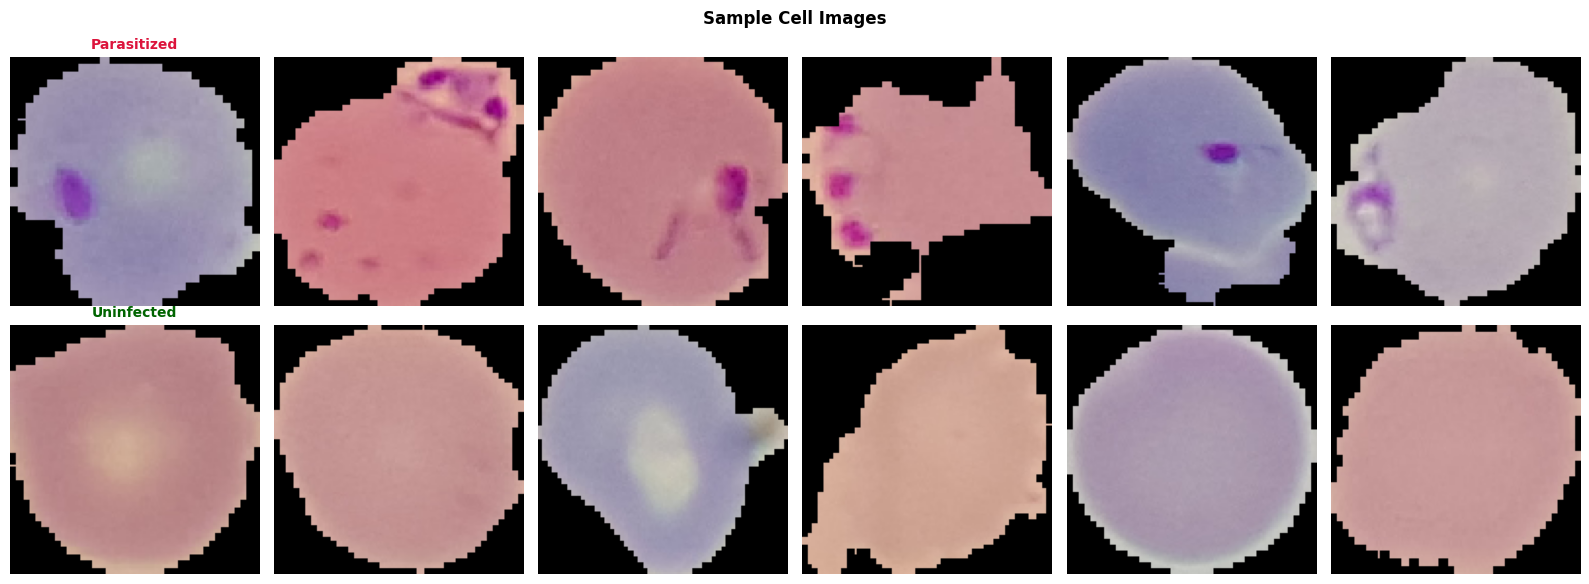

In [9]:
cls_names = list(train_gen.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample Cell Images', fontsize=12, fontweight='bold')
imgs, lbls = next(train_gen)
shown = {0:0, 1:0}
for img, lbl in zip(imgs, lbls):
    lbl = int(lbl); col = shown[lbl]
    if col < 6:
        axes[lbl, col].imshow(img); axes[lbl, col].axis('off')
        if col == 0:
            axes[lbl, col].set_title(cls_names[lbl], fontsize=10,
                color='crimson' if lbl==0 else 'darkgreen', fontweight='bold')
        shown[lbl] += 1
    if shown[0]==6 and shown[1]==6: break
pyplot.tight_layout(); pyplot.show()

### Evaluation Utilities

These helper functions are shared across all experiments in the notebook. `plot_learning_curves()` shows how training and validation accuracy evolved over epochs. `evaluate_model()` computes all the key metrics and plots the confusion matrix and ROC curve. `results_table()` gives a clean side-by-side summary of every experiment.

In [10]:
def plot_learning_curves(history, name='Model'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    ep = range(1, len(acc)+1)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{name} -- Learning Curves', fontsize=13, fontweight='bold')
    a1.plot(ep, acc, 'b-o', ms=3, label='Train')
    a1.plot(ep, val_acc, 'r-o', ms=3, label='Test')
    a1.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=[0,1])
    a1.legend(); a1.grid(alpha=0.3)
    a2.plot(ep, loss, 'b-o', ms=3, label='Train')
    a2.plot(ep, val_loss, 'r-o', ms=3, label='Test')
    a2.set(title='Loss', xlabel='Epoch', ylabel='Binary Cross-Entropy')
    a2.legend(); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_curves.png', dpi=150, bbox_inches='tight')
    pyplot.show()


def evaluate_model(model, gen, name='Model', threshold=0.5):
    gen.reset()
    probs  = model.predict(gen, verbose=0).flatten()
    yp     = (probs >= threshold).astype(int)
    yt     = gen.classes
    cnames = list(gen.class_indices.keys())
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    fpr, tpr, _ = roc_curve(yt, 1-probs, pos_label=0)
    roc_auc = auc(fpr, tpr)
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC       : {roc_auc:.4f}')
    print(f'{"="*50}')
    print(classification_report(yt, yp, target_names=cnames))
    cm = confusion_matrix(yt, yp)
    fig, (a1, a2) = pyplot.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=a1,
                xticklabels=cnames, yticklabels=cnames)
    a1.set(title=f'{name} -- Confusion Matrix',
           xlabel='Predicted', ylabel='True')
    tn, fp, fn, tp = cm.ravel()
    a1.text(0.5, -0.13, f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
            transform=a1.transAxes, ha='center', fontsize=9, color='navy')
    a2.plot(fpr, tpr, 'darkorange', lw=2, label=f'AUC={roc_auc:.4f}')
    a2.fill_between(fpr, tpr, alpha=0.07, color='darkorange')
    a2.plot([0,1],[0,1],'navy',lw=1.5,ls='--',label='Random (AUC=0.5)')
    a2.set(xlim=[0,1], ylim=[0,1.02], title=f'{name} -- ROC/AUC',
           xlabel='False Positive Rate', ylabel='True Positive Rate')
    a2.legend(loc='lower right'); a2.grid(alpha=0.3)
    pyplot.tight_layout()
    pyplot.savefig(name.replace(' ','_')+'_eval.png', dpi=150, bbox_inches='tight')
    pyplot.show()
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=roc_auc)


def results_table(experiments):
    hdr = (f"{'Exp':>4} | {'Description':<35} | "
           f"{'Acc':>6} | {'Prec':>6} | {'Rec':>6} | {'F1':>6} | {'AUC':>6}")
    sep = '='*len(hdr)
    print(f'\n{sep}\n{hdr}\n{sep}')
    for e in experiments:
        print(f"{e['id']:>4} | {e['desc']:<35} | {e['accuracy']:.4f} | "
              f"{e['precision']:.4f} | {e['recall']:.4f} | "
              f"{e['f1']:.4f} | {e['auc']:.4f}")
    print(sep)


def get_callbacks(name):
    os.makedirs('saved_models', exist_ok=True)
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(f'saved_models/{name}.keras',
                                  monitor='val_accuracy', save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-7, verbose=1)
    ]

print('Evaluation utilities ready.')

Evaluation utilities ready.


In [11]:
import os

# Where to save trained models.
# On Colab with Drive mounted, this saves to Drive so models survive disconnections.
# If Drive isn't available, we fall back to a local folder.
_drive_save = '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models'
_local_save = 'saved_models'

if os.path.exists('/content/drive'):
    SAVE_DIR = _drive_save
    print(f"Saving models to Google Drive: {SAVE_DIR}")
else:
    SAVE_DIR = _local_save
    print(f"Drive not mounted — saving models locally to: {SAVE_DIR}")

os.makedirs(SAVE_DIR, exist_ok=True)


def train_or_load(name, model, tg, eg):
    """Train a model or load existing weights if already saved."""
    path = os.path.join(SAVE_DIR, name + '.keras')
    if os.path.exists(path):
        print(f"  Found saved model for {name} — loading weights from {path}")
        model = tf.keras.models.load_model(path)
        return model, None
    print(f"  No saved model found for {name} — starting training...")
    history = model.fit(
        tg,
        epochs=EPOCHS_MAX,
        validation_data=eg,
        callbacks=get_callbacks(name),
        verbose=1
    )
    model.save(path)
    print(f"  Model saved → {path}")
    return model, history


Saving models to Google Drive: /content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models


In [12]:
def make_mobilenet_generators(batch_size=64, aug=False):
    return make_generators(batch_size=batch_size, aug=aug, preprocess_fn=mobilenet_v2_preprocess)

print('make_mobilenet_generators ready.')

make_mobilenet_generators ready.


---
## MobileNetV2 Transfer Learning Experiments

**Gabriel SEZIBERA Tuyisingize**

**Why I find this model interesting for this problem**

MobileNetV2 is built to be efficient and it achieves good accuracy with far fewer parameters than VGG16 or ResNet50. The main technique it uses is depthwise separable convolution which splits a regular convolution into two smaller steps and that cuts computation by about 8 to 9 times without losing much accuracy. It also uses inverted residual blocks where each block first expands the number of channels, does the convolution and then compresses back down which keeps the model lightweight while still learning useful features. For malaria diagnosis specifically this matters a lot because many hospitals in Africa where malaria is most common do not have powerful computers and a model that can run on a basic device is actually useful in those settings. Like ResNet50 I kept the BatchNormalization layers frozen during fine-tuning and my classifier head uses GlobalAveragePooling2D, a Dense layer, Dropout at 0.4 and a sigmoid output.

| Exp | What changes | What I'm testing |
|-----|-------------|------------------|
| 1 | All layers frozen, GAP head | Whether ImageNet features alone are useful for malaria cells |
| 2 | Unfreeze last 10 layers, lr=1e-5 | A light touch of fine-tuning on the top blocks |
| 3 | Unfreeze last 20 layers, lr=1e-5 | Moderate fine-tuning  more features adapted to our data |
| 4 | Unfreeze last 40 layers, lr=1e-5 | Aggressive fine-tuning more flexibility, more overfitting risk |
| 5 | Frozen backbone + augmentation | Does augmentation alone improve generalization? |
| 6 | Unfreeze 20 layers + augmentation, lr=1e-5 | Best of both worlds fine-tuning and regularization together |
| 7 | Frozen + wider Dense head (512 units) | Does a bigger classifier head capture more complex patterns? |

In [13]:
def build_mobilenet(unfreeze_last=0, dense_units=256, lr=1e-4):
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
    base.trainable = False
    if unfreeze_last > 0:
        for layer in base.layers[-unfreeze_last:]:
            if not isinstance(layer, BatchNormalization):
                layer.trainable = True
    inp = Input(shape=(128,128,3))
    x   = base(inp, training=False)
    x   = GlobalAveragePooling2D()(x)
    x   = Dense(dense_units, activation='relu')(x)
    x   = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out, name='MobileNetV2_TL')
    model.compile(optimizer=optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

build_mobilenet().summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Experiment 1: Frozen Backbone, GAP Head (Baseline)

This is my transfer learning baseline where the backbone is completely frozen and only the head trains and because MobileNetV2 already has far fewer parameters than VGG16 or ResNet50 the risk of overfitting is quite low right from the start.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
  Found saved model for G_exp1 — loading weights from /content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/saved_models/G_exp1.keras

  Gabriel Exp1
  Accuracy  : 0.9470
  Precision : 0.9384
  Recall    : 0.9568
  F1-Score  : 0.9475
  AUC       : 0.9850
              precision    recall  f1-score   support

 Parasitized       0.96      0.94      0.95      2756
  Uninfected       0.94      0.96      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



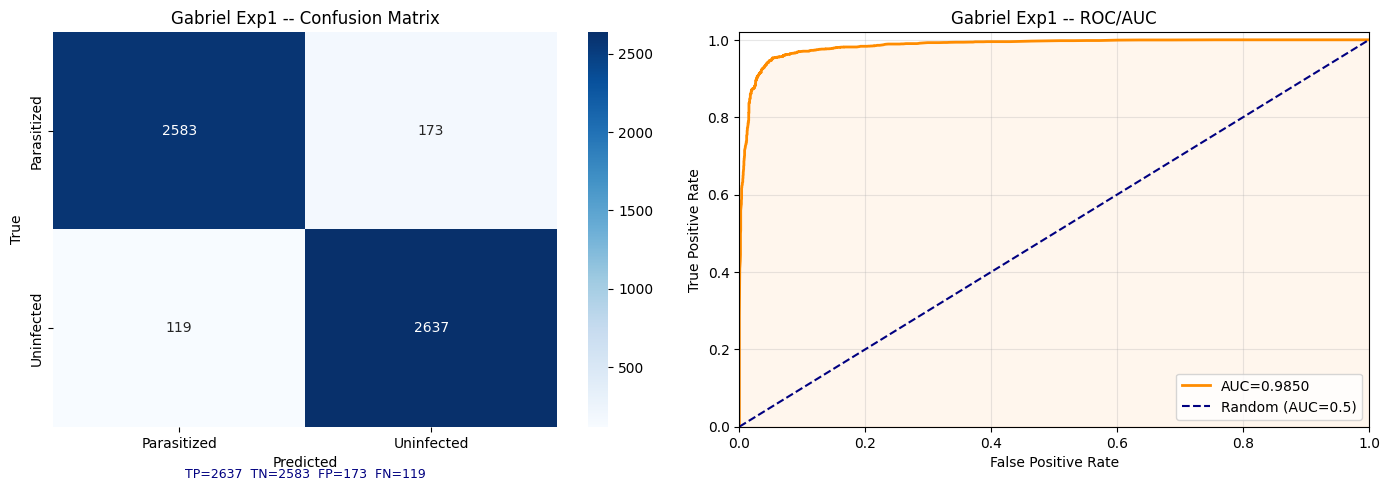

In [14]:
tg, eg = make_mobilenet_generators()
g1 = build_mobilenet(0, 256, 1e-4)
g1, hg1 = train_or_load('G_exp1', g1, tg, eg)
if hg1: plot_learning_curves(hg1, 'Gabriel Exp1')
rg1 = evaluate_model(g1, eg, 'Gabriel Exp1')

#### Experiment 2: Unfreeze Last 10 Layers (lr=1e-5)

I unfroze the last 10 layers while keeping all BatchNormalization layers frozen and this small fine-tuning step lets the top inverted residual blocks start adapting their features toward malaria cell images without changing too much at once.

  No saved model found for G_exp2 — starting training...
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 122s 278ms/step - accuracy: 0.8267 - loss: 0.3737 - val_accuracy: 0.9078 - val_loss: 0.2383 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9063 - loss: 0.2328 - val_accuracy: 0.9283 - val_loss: 0.1980 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 97ms/step - accuracy: 0.9227 - loss: 0.2029 - val_accuracy: 0.9331 - val_loss: 0.1857 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step - accuracy: 0.9296 - loss: 0.1850 - val_accuracy: 0.9331 - val_loss: 0.1923 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.9346 - loss: 0.1753 - val_accuracy: 0.9419 - val_loss: 0.1685 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.9388 - loss: 0.1673 - val_accuracy: 0.9421 - val_loss: 0.1657 - learning_rate: 1.00

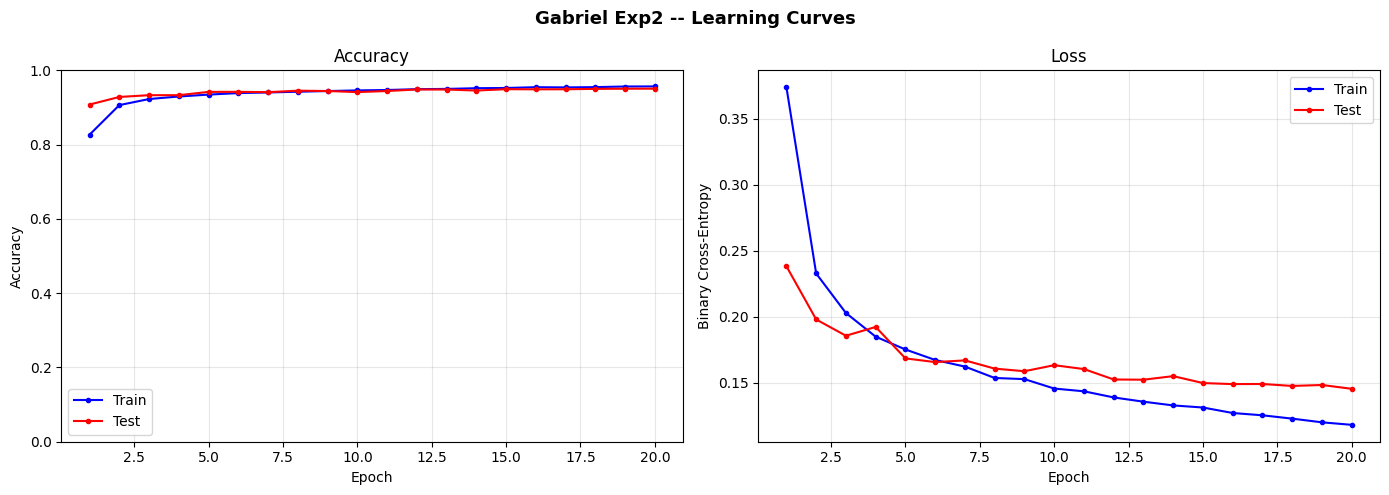


  Gabriel Exp2
  Accuracy  : 0.9507
  Precision : 0.9455
  Recall    : 0.9565
  F1-Score  : 0.9509
  AUC       : 0.9861
              precision    recall  f1-score   support

 Parasitized       0.96      0.94      0.95      2756
  Uninfected       0.95      0.96      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



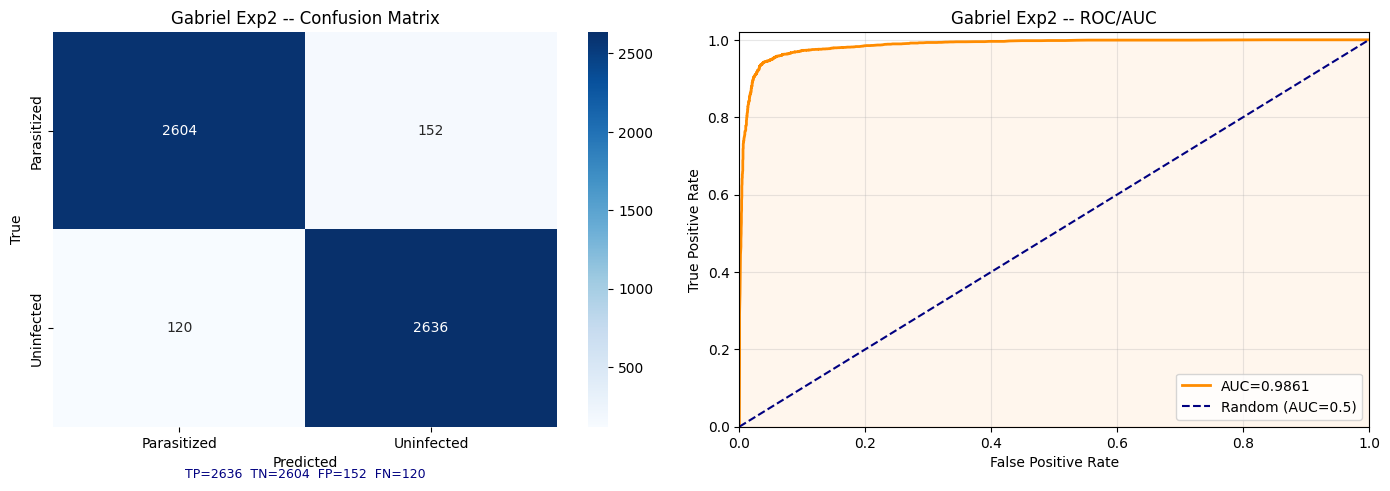

In [15]:
g2 = build_mobilenet(10, 256, 1e-5)
g2, hg2 = train_or_load('G_exp2', g2, tg, eg)
if hg2: plot_learning_curves(hg2, 'Gabriel Exp2')
rg2 = evaluate_model(g2, eg, 'Gabriel Exp2')

#### Experiment 3: Unfreeze Last 20 Layers (lr=1e-5)

I unfroze 20 layers this time to give more of the model the chance to adapt and I expected that having more layers free to change their features would push accuracy above what Experiment 2 achieved.

  No saved model found for G_exp3 — starting training...
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 113s 258ms/step - accuracy: 0.8712 - loss: 0.2947 - val_accuracy: 0.9303 - val_loss: 0.1968 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.9310 - loss: 0.1856 - val_accuracy: 0.9445 - val_loss: 0.1661 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9424 - loss: 0.1593 - val_accuracy: 0.9458 - val_loss: 0.1538 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9495 - loss: 0.1459 - val_accuracy: 0.9510 - val_loss: 0.1467 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.9519 - loss: 0.1344 - val_accuracy: 0.9510 - val_loss: 0.1436 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 37s 107ms/step - accuracy: 0.9550 - loss: 0.1280 - val_accuracy: 0.9526 - val_loss: 0.1427 - learning_rate: 1.0

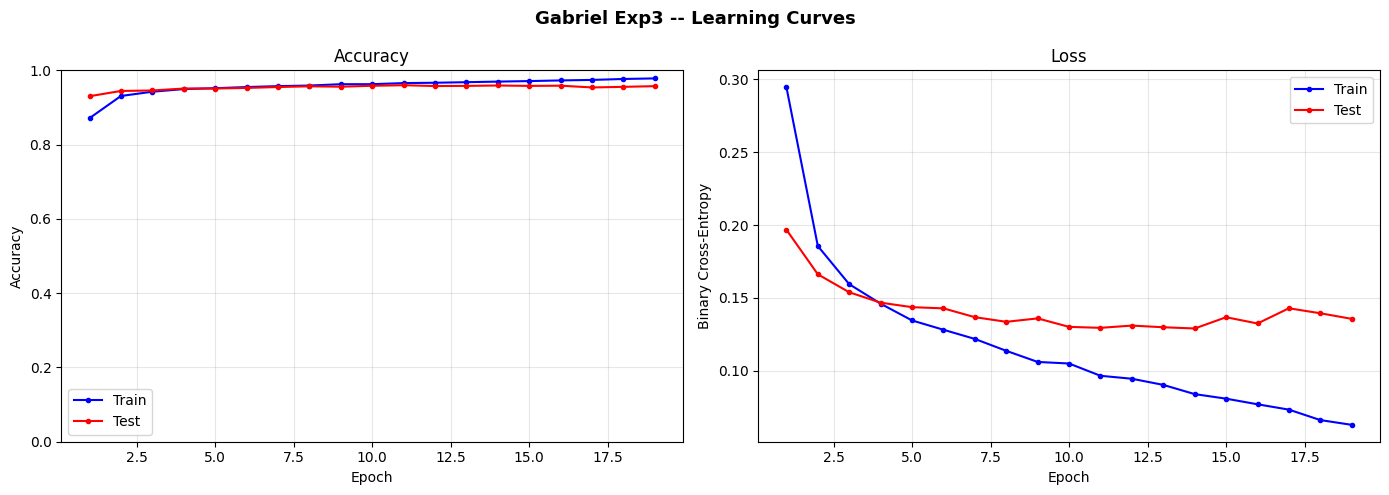


  Gabriel Exp3
  Accuracy  : 0.9592
  Precision : 0.9521
  Recall    : 0.9670
  F1-Score  : 0.9595
  AUC       : 0.9895
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2756
  Uninfected       0.95      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



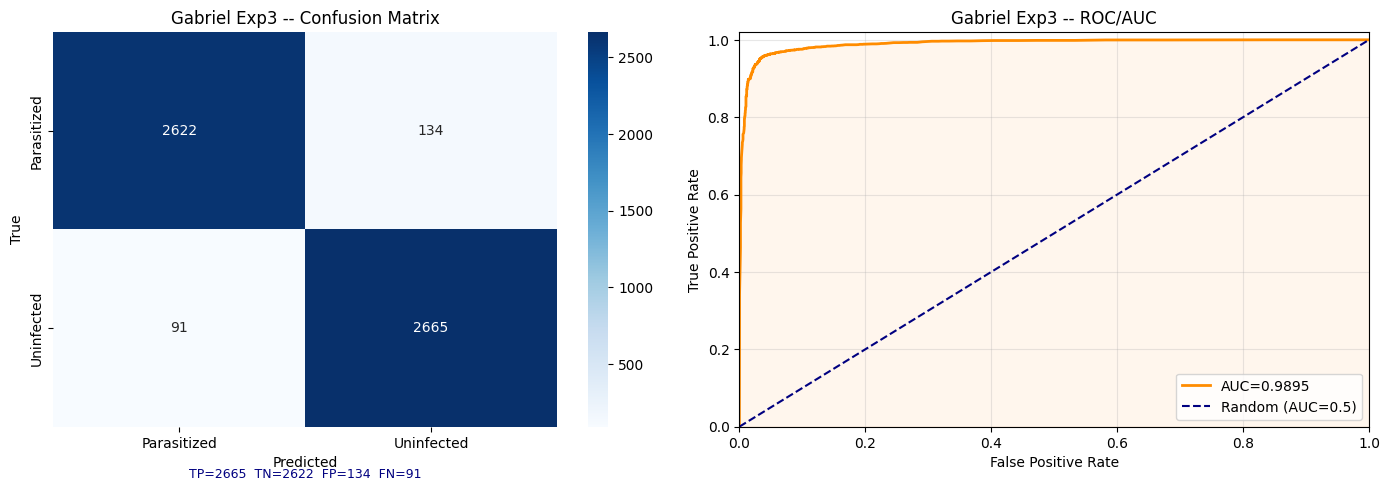

In [16]:
g3 = build_mobilenet(20, 256, 1e-5)
g3, hg3 = train_or_load('G_exp3', g3, tg, eg)
if hg3: plot_learning_curves(hg3, 'Gabriel Exp3')
rg3 = evaluate_model(g3, eg, 'Gabriel Exp3')

#### Experiment 4: Unfreeze Last 40 Layers (lr=1e-5)

I unfroze 40 layers here which is the deepest fine-tuning in my experiments and I wanted to see if having that many layers adapting to the malaria images would push accuracy higher without causing serious overfitting along the way.

  No saved model found for G_exp4 — starting training...
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 120s 259ms/step - accuracy: 0.8901 - loss: 0.2630 - val_accuracy: 0.9370 - val_loss: 0.1733 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - accuracy: 0.9450 - loss: 0.1553 - val_accuracy: 0.9516 - val_loss: 0.1410 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - accuracy: 0.9524 - loss: 0.1340 - val_accuracy: 0.9525 - val_loss: 0.1399 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - accuracy: 0.9571 - loss: 0.1200 - val_accuracy: 0.9550 - val_loss: 0.1290 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - accuracy: 0.9609 - loss: 0.1124 - val_accuracy: 0.9575 - val_loss: 0.1286 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 34s 98ms/step - accuracy: 0.9640 - loss: 0.1036 - val_accuracy: 0.9590 - val_loss: 0.1197 - learning_rate: 1.0

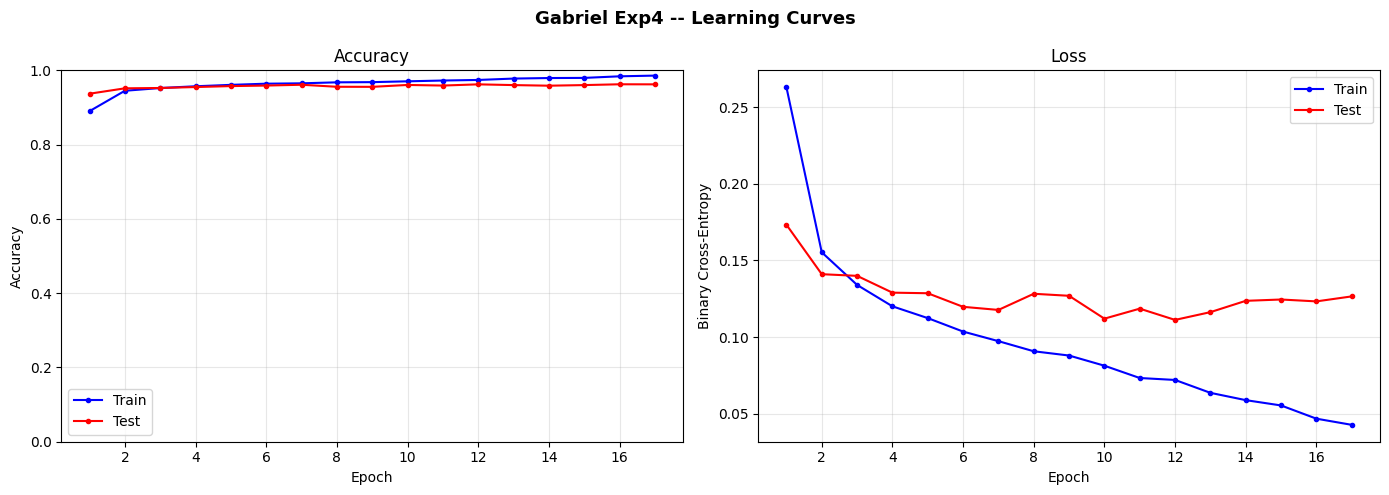


  Gabriel Exp4
  Accuracy  : 0.9623
  Precision : 0.9547
  Recall    : 0.9706
  F1-Score  : 0.9626
  AUC       : 0.9923
              precision    recall  f1-score   support

 Parasitized       0.97      0.95      0.96      2756
  Uninfected       0.95      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



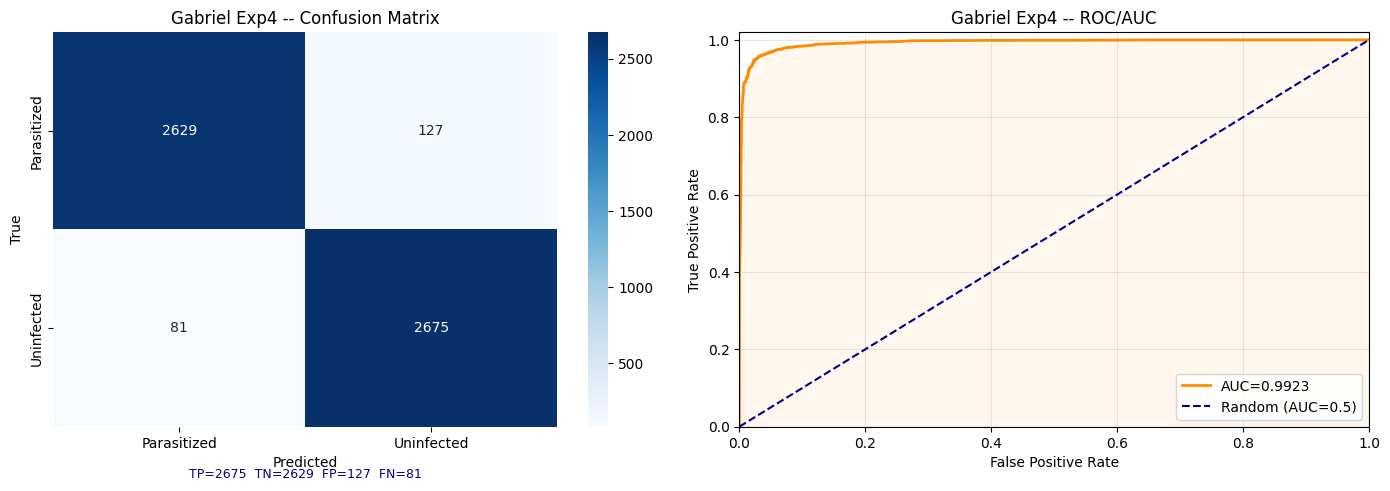

In [17]:
g4 = build_mobilenet(40, 256, 1e-5)
g4, hg4 = train_or_load('G_exp4', g4, tg, eg)
if hg4: plot_learning_curves(hg4, 'Gabriel Exp4')
rg4 = evaluate_model(g4, eg, 'Gabriel Exp4')

#### Experiment 5: Frozen Backbone + Data Augmentation

I kept the backbone frozen here and just added augmentation to test whether showing the head more varied versions of the training images is enough to improve generalization on its own without touching any of the backbone layers.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
  No saved model found for G_exp5 — starting training...
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 181s 464ms/step - accuracy: 0.8509 - loss: 0.3376 - val_accuracy: 0.8913 - val_loss: 0.2626 - learning_rate: 1.0000e-04
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 114s 331ms/step - accuracy: 0.9031 - loss: 0.2479 - val_accuracy: 0.8862 - val_loss: 0.2619 - learning_rate: 1.0000e-04
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 115s 333ms/step - accuracy: 0.9084 - loss: 0.2304 - val_accuracy: 0.9115 - val_loss: 0.2188 - learning_rate: 1.0000e-04
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 113s 327ms/step - accuracy: 0.9143 - loss: 0.2186 - val_accuracy: 0.9013 - val_loss: 0.2344 - learning_rate: 1.0000e-04
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 116s 336ms/step - accuracy: 0.9190 - loss: 0.2134 - val_accuracy: 0.9124 - val_loss: 0.2189 - learning_rate: 1.0000e-04
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - ac

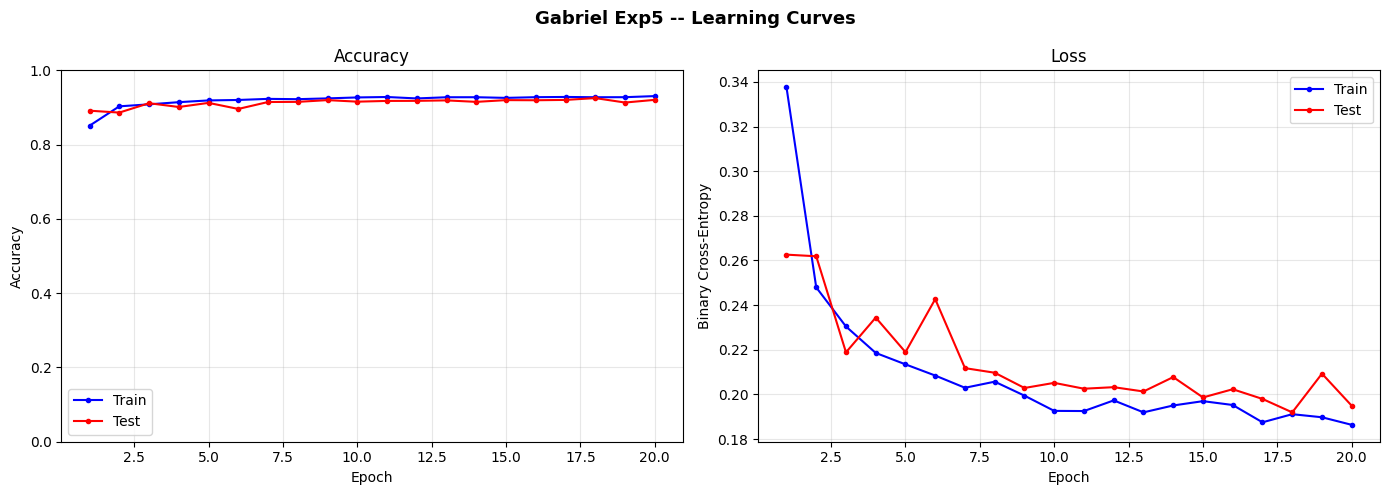


  Gabriel Exp5
  Accuracy  : 0.9253
  Precision : 0.8968
  Recall    : 0.9612
  F1-Score  : 0.9278
  AUC       : 0.9798
              precision    recall  f1-score   support

 Parasitized       0.96      0.89      0.92      2756
  Uninfected       0.90      0.96      0.93      2756

    accuracy                           0.93      5512
   macro avg       0.93      0.93      0.93      5512
weighted avg       0.93      0.93      0.93      5512



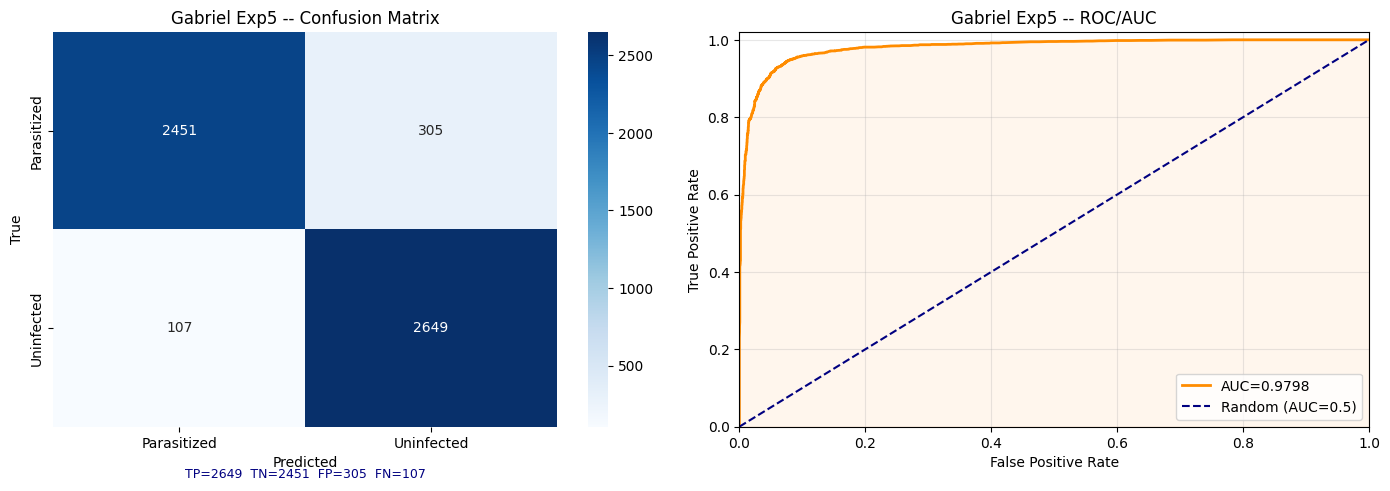

In [18]:
tg_aug, eg = make_mobilenet_generators(aug=True)
g5 = build_mobilenet(0, 256, 1e-4)
g5, hg5 = train_or_load('G_exp5', g5, tg_aug, eg)
if hg5: plot_learning_curves(hg5, 'Gabriel Exp5')
rg5 = evaluate_model(g5, eg, 'Gabriel Exp5')

#### Experiment 6: Unfreeze 20 Layers + Augmentation (lr=1e-5)

I combined moderate fine-tuning with augmentation here so the features get to adapt to malaria images while augmentation helps stop the head from overfitting and I expected this configuration to give the best results out of all my experiments.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
  No saved model found for G_exp6 — starting training...
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 186s 472ms/step - accuracy: 0.8581 - loss: 0.3253 - val_accuracy: 0.8908 - val_loss: 0.2560 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 118s 342ms/step - accuracy: 0.9163 - loss: 0.2178 - val_accuracy: 0.9287 - val_loss: 0.1894 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 114s 329ms/step - accuracy: 0.9261 - loss: 0.1961 - val_accuracy: 0.9002 - val_loss: 0.2376 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 116s 336ms/step - accuracy: 0.9343 - loss: 0.1783 - val_accuracy: 0.9383 - val_loss: 0.1673 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 117s 339ms/step - accuracy: 0.9382 - loss: 0.1671 - val_accuracy: 0.9474 - val_loss: 0.1560 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 114s 329ms/step - 

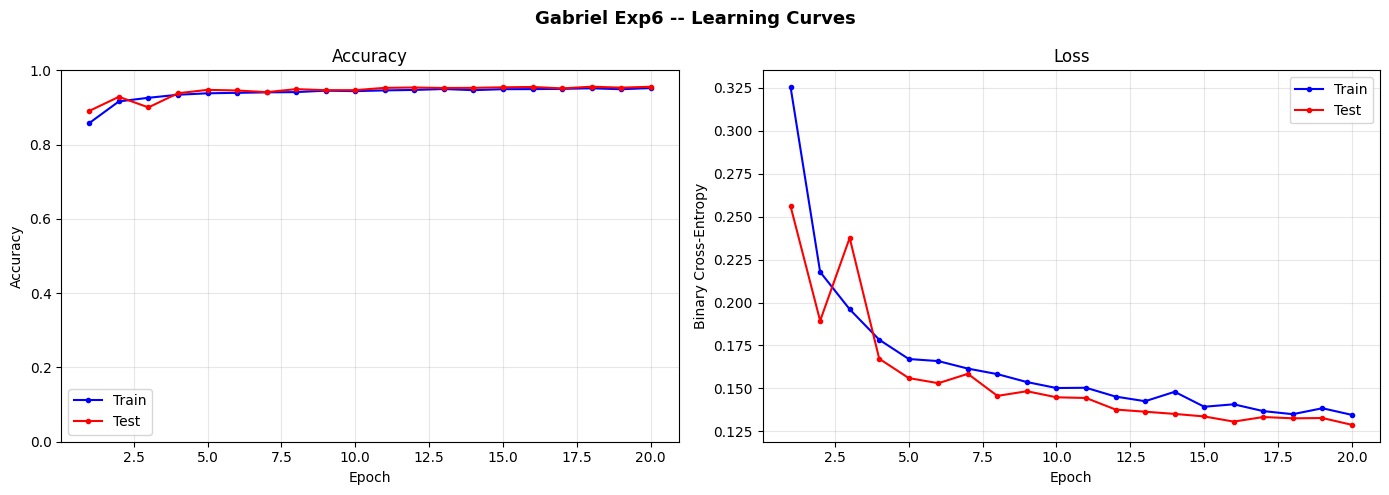


  Gabriel Exp6
  Accuracy  : 0.9557
  Precision : 0.9432
  Recall    : 0.9699
  F1-Score  : 0.9564
  AUC       : 0.9893
              precision    recall  f1-score   support

 Parasitized       0.97      0.94      0.96      2756
  Uninfected       0.94      0.97      0.96      2756

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



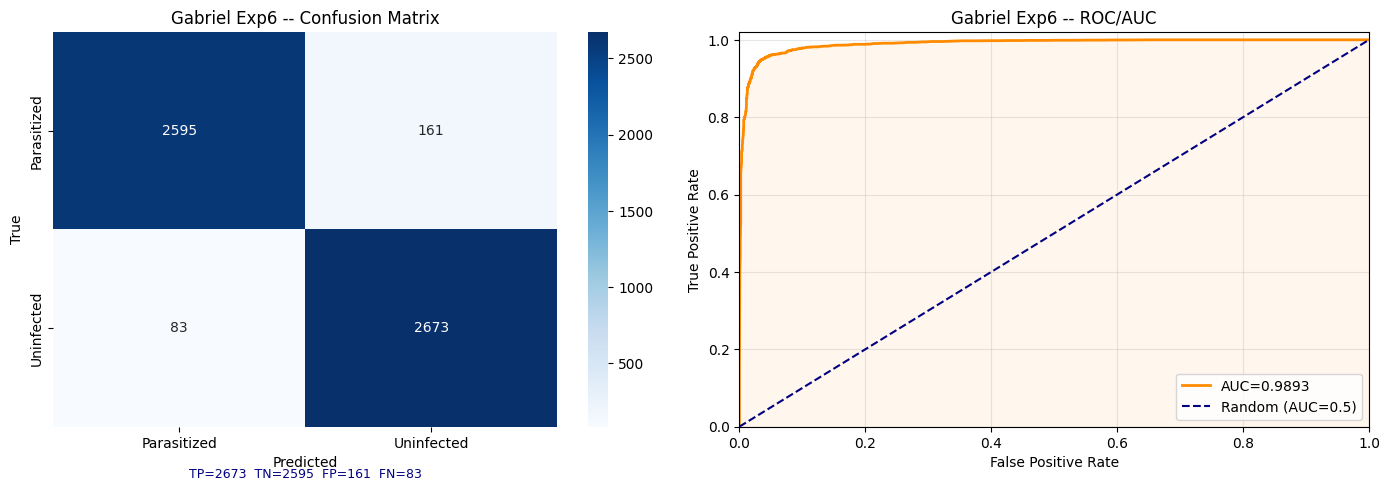

In [19]:
tg_aug, eg = make_mobilenet_generators(aug=True)
g6 = build_mobilenet(20, 256, 1e-5)
g6, hg6 = train_or_load('G_exp6', g6, tg_aug, eg)
if hg6: plot_learning_curves(hg6, 'Gabriel Exp6')
rg6 = evaluate_model(g6, eg, 'Gabriel Exp6')

#### Experiment 7: Frozen Backbone, Wider Head (512 Units)

I kept the backbone frozen but doubled the head size to 512 neurons to test whether a bigger classifier can learn more complex patterns though without augmentation those extra parameters are more likely to start memorizing the training data.

Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
  No saved model found for G_exp7 — starting training...
Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 105s 247ms/step - accuracy: 0.8724 - loss: 0.2960 - val_accuracy: 0.9231 - val_loss: 0.2079 - learning_rate: 1.0000e-04
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.9194 - loss: 0.2090 - val_accuracy: 0.9292 - val_loss: 0.2012 - learning_rate: 1.0000e-04
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.9291 - loss: 0.1881 - val_accuracy: 0.9338 - val_loss: 0.1793 - learning_rate: 1.0000e-04
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.9340 - loss: 0.1773 - val_accuracy: 0.9358 - val_loss: 0.1740 - learning_rate: 1.0000e-04
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 34s 100ms/step - accuracy: 0.9366 - loss: 0.1692 - val_accuracy: 0.9398 - val_loss: 0.1686 - learning_rate: 1.0000e-04
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 33s 97ms/step - accuracy

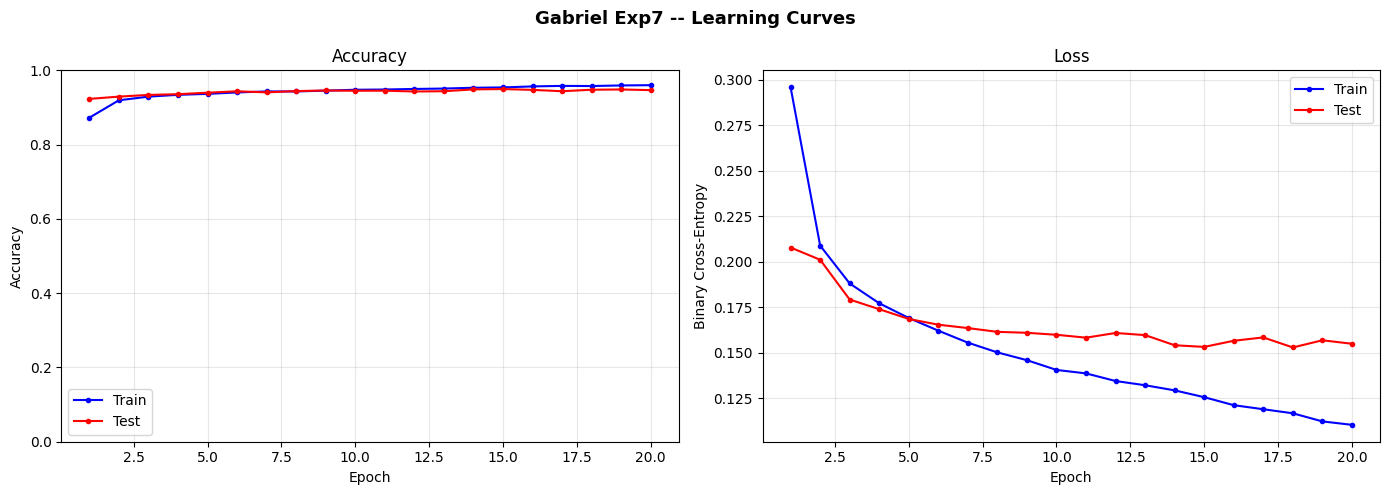


  Gabriel Exp7
  Accuracy  : 0.9478
  Precision : 0.9423
  Recall    : 0.9539
  F1-Score  : 0.9481
  AUC       : 0.9852
              precision    recall  f1-score   support

 Parasitized       0.95      0.94      0.95      2756
  Uninfected       0.94      0.95      0.95      2756

    accuracy                           0.95      5512
   macro avg       0.95      0.95      0.95      5512
weighted avg       0.95      0.95      0.95      5512



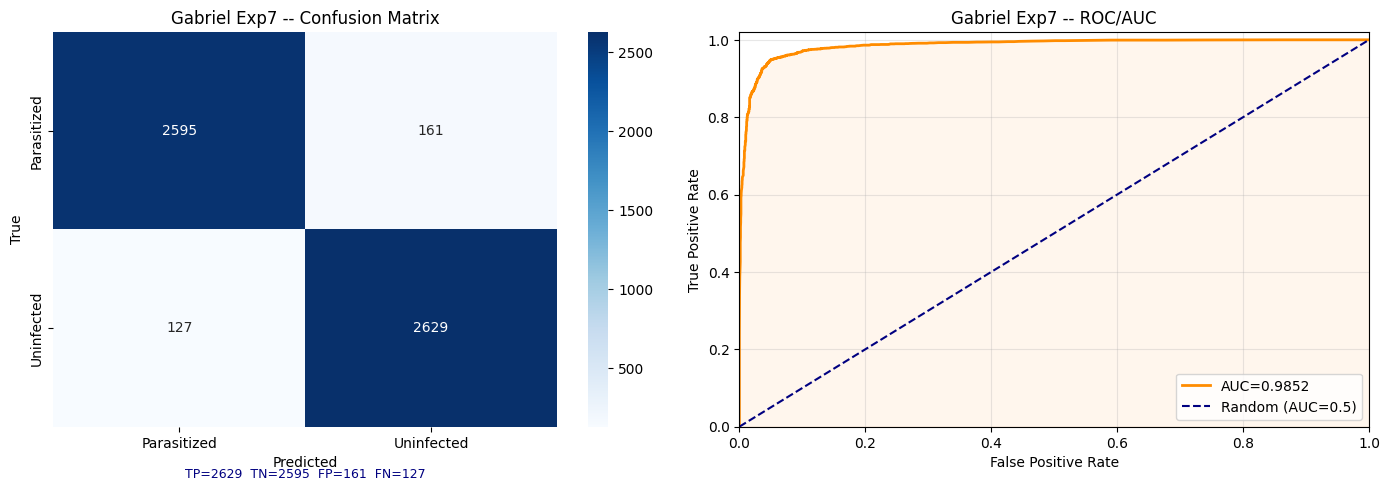

In [20]:
tg, eg = make_mobilenet_generators()
g7 = build_mobilenet(0, 512, 1e-4)
g7, hg7 = train_or_load('G_exp7', g7, tg, eg)
if hg7: plot_learning_curves(hg7, 'Gabriel Exp7')
rg7 = evaluate_model(g7, eg, 'Gabriel Exp7')

#### Experiment Results

In [21]:
gabriel_res = [
    {'id':1,'desc':'MobileNetV2 frozen',**rg1},
    {'id':2,'desc':'Unfreeze 10 lr=1e-5',**rg2},
    {'id':3,'desc':'Unfreeze 20 lr=1e-5',**rg3},
    {'id':4,'desc':'Unfreeze 40 lr=1e-5',**rg4},
    {'id':5,'desc':'Frozen + aug',**rg5},
    {'id':6,'desc':'Unfreeze 20 + aug',**rg6},
    {'id':7,'desc':'Frozen wider 512',**rg7},
]
print('GABRIEL SEZIBERA -- MobileNetV2')
results_table(gabriel_res)
best_g = max(gabriel_res, key=lambda x: x['f1'])
print(f'Best: Exp {best_g["id"]} | F1={best_g["f1"]:.4f} | AUC={best_g["auc"]:.4f}')

GABRIEL SEZIBERA -- MobileNetV2

 Exp | Description                         |    Acc |   Prec |    Rec |     F1 |    AUC
   1 | MobileNetV2 frozen                  | 0.9470 | 0.9384 | 0.9568 | 0.9475 | 0.9850
   2 | Unfreeze 10 lr=1e-5                 | 0.9507 | 0.9455 | 0.9565 | 0.9509 | 0.9861
   3 | Unfreeze 20 lr=1e-5                 | 0.9592 | 0.9521 | 0.9670 | 0.9595 | 0.9895
   4 | Unfreeze 40 lr=1e-5                 | 0.9623 | 0.9547 | 0.9706 | 0.9626 | 0.9923
   5 | Frozen + aug                        | 0.9253 | 0.8968 | 0.9612 | 0.9278 | 0.9798
   6 | Unfreeze 20 + aug                   | 0.9557 | 0.9432 | 0.9699 | 0.9564 | 0.9893
   7 | Frozen wider 512                    | 0.9478 | 0.9423 | 0.9539 | 0.9481 | 0.9852
Best: Exp 4 | F1=0.9626 | AUC=0.9923


Found 22046 images belonging to 2 classes.
Found 5512 images belonging to 2 classes.
Gabriel (MobileNetV2) Best Exp 4
  Total misclassified : 208
  False Negatives (missed parasites) : 127
  False Positives (false alarms)     : 81


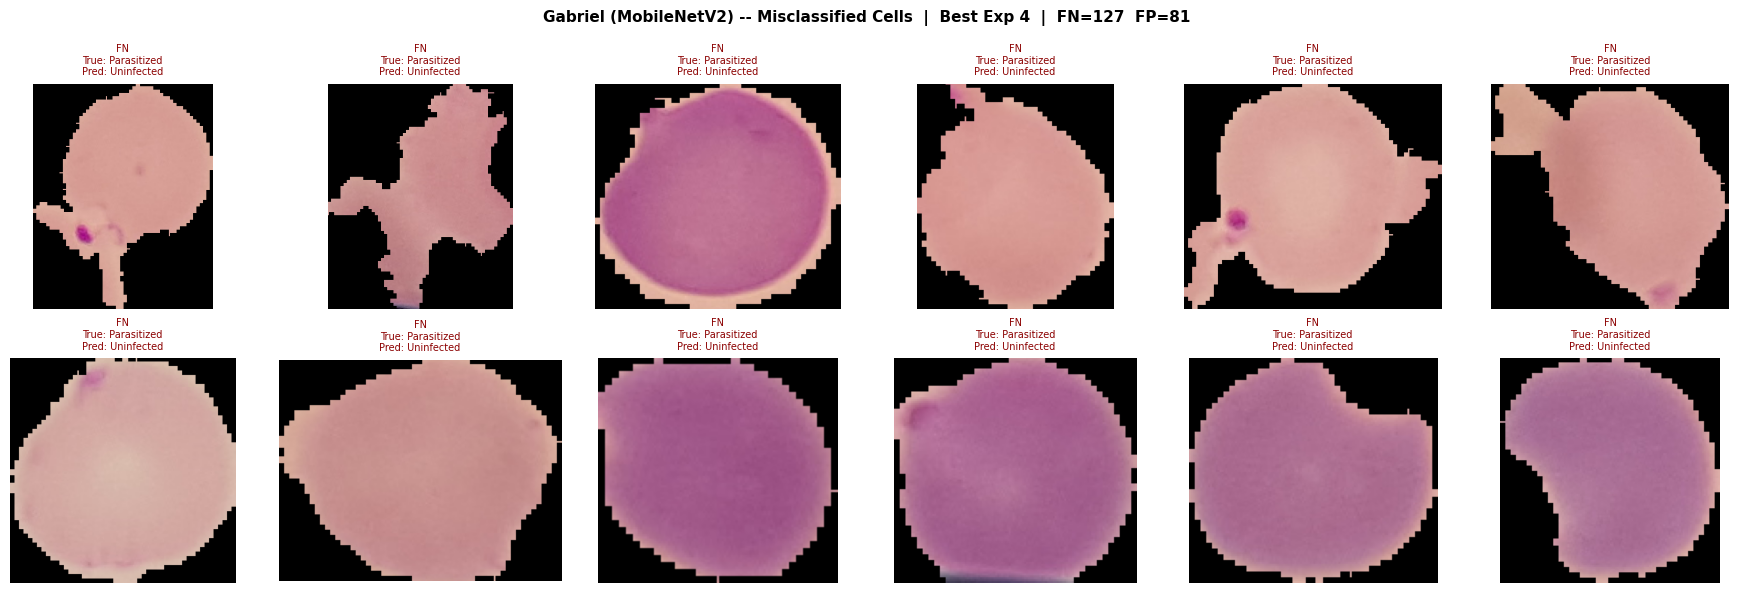

In [22]:
# Gabriel — Error Analysis (best-experiment misclassification grid)
tg_tmp, eg_tmp = make_mobilenet_generators()
all_g_models = [g1, g2, g3, g4, g5, g6, g7]
bm_g = all_g_models[best_g['id'] - 1]
eg_tmp.reset()
probs_g_err = bm_g.predict(eg_tmp, verbose=0).flatten()
yp_g_err    = (probs_g_err >= 0.5).astype(int)
yt_g_err    = eg_tmp.classes
wrong_g     = np.where(yp_g_err != yt_g_err)[0]
fn_g = [idx for idx in wrong_g if yt_g_err[idx]==0 and yp_g_err[idx]==1]
fp_g = [idx for idx in wrong_g if yt_g_err[idx]==1 and yp_g_err[idx]==0]
print(f'Gabriel (MobileNetV2) Best Exp {best_g["id"]}')
print(f'  Total misclassified : {len(wrong_g)}')
print(f'  False Negatives (missed parasites) : {len(fn_g)}')
print(f'  False Positives (false alarms)     : {len(fp_g)}')
cnames_g = list(eg_tmp.class_indices.keys())
fig, axes = pyplot.subplots(2, 6, figsize=(18, 6))
fig.suptitle(f'Gabriel (MobileNetV2) -- Misclassified Cells  |  Best Exp {best_g["id"]}  |  FN={len(fn_g)}  FP={len(fp_g)}',
             fontsize=11, fontweight='bold')
for i_e, idx in enumerate(wrong_g[:12]):
    row, col = divmod(i_e, 6)
    axes[row, col].imshow(pyplot.imread(eg_tmp.filepaths[idx]))
    axes[row, col].axis('off')
    err_type = 'FN' if (yt_g_err[idx]==0 and yp_g_err[idx]==1) else 'FP'
    axes[row, col].set_title(
        f'{err_type}\nTrue: {cnames_g[yt_g_err[idx]]}\nPred: {cnames_g[yp_g_err[idx]]}',
        fontsize=7, color='darkred')
pyplot.tight_layout()
pyplot.savefig('Gabriel_error_analysis.png', dpi=150, bbox_inches='tight')
pyplot.show()

#### What Worked and What Did Not

**Going through each run**

MobileNetV2 already has fewer parameters than VGG16 and ResNet50 so the overfitting risk was lower from the beginning and in Experiment 1 where only the head trained the training and validation accuracy stayed fairly close to each other though the model might have underfit a little since ImageNet features were not made for malaria microscopy images.

**Experiments 2, 3 and 4 (unfreezing layers):** Unfreezing 10 or 20 layers helped the model adapt its features to the malaria image style without too much risk and unfreezing 40 layers gave more freedom to adapt but also meant more parameters could start overfitting so a growing gap between training and validation accuracy in Experiment 4 would confirm that.

**Experiment 5 (augmentation without fine-tuning):** Adding augmentation while the backbone stays frozen tests whether more variety in training alone is enough to improve generalization without changing the backbone weights at all.

**Experiment 6 (20 layers with augmentation):** This combined moderate fine-tuning with the regularization that augmentation brings and I expected this to give the best validation performance for MobileNetV2 because both approaches work together without either one going too far.

**Experiment 7 (wider head with 512 units):** A bigger head has more parameters and without augmentation those extra parameters are quite likely to overfit the training data which would show up as a growing gap between training and validation accuracy as the epochs progress.

**Error Analysis:**

The images above show the cells that the best MobileNetV2 model got wrong. False Negatives are the most important errors to minimize because they mean a parasitized cell was called healthy and in a real clinical situation that means a sick person does not get treatment. False Positives are less dangerous but still show where the model is getting confused and looking at these images tells us whether the errors come from image quality issues or from cells that genuinely look very similar between the two classes.